In [19]:
import zipfile

zip_path = "/content/Traffic.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [20]:
import zipfile

with zipfile.ZipFile("/content/Traffic.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/Traffic")

print(os.listdir("/content/Traffic"))

['video.mp4', 'car']


In [21]:
for root, dirs, files in os.walk('/content/Traffic'):
    print(root, dirs[:5])

/content/Traffic ['car']
/content/Traffic/car ['valid', 'test', 'train']
/content/Traffic/car/valid ['labels', 'images']
/content/Traffic/car/valid/labels []
/content/Traffic/car/valid/images []
/content/Traffic/car/test ['labels', 'images']
/content/Traffic/car/test/labels []
/content/Traffic/car/test/images []
/content/Traffic/car/train ['labels', 'images']
/content/Traffic/car/train/labels []
/content/Traffic/car/train/images []


In [22]:
Image_dir = "/content/Traffic/train/images"

In [23]:
!pip install ultralytics


In [24]:
# Import Essential Libraries
import os
import random
import pandas as pd
from PIL import Image
import cv2
from ultralytics import YOLO
from IPython.display import Video
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
import pathlib
import glob
from tqdm.notebook import trange, tqdm
import warnings
warnings.filterwarnings('ignore')

In [25]:
sns.set(rc={'axes.facecolor': '#eae8fa'}, style='darkgrid')


In [26]:
import os
print(os.getcwd())
print(os.path.exists('/kaggle'))
print(os.path.exists('/content'))

/content
True
True


In [27]:
Image_dir = "/content/Traffic/train/images"

In [28]:
import os

for root, dirs, files in os.walk('/content/Traffic'):
    print(root)

/content/Traffic
/content/Traffic/car
/content/Traffic/car/valid
/content/Traffic/car/valid/labels
/content/Traffic/car/valid/images
/content/Traffic/car/test
/content/Traffic/car/test/labels
/content/Traffic/car/test/images
/content/Traffic/car/train
/content/Traffic/car/train/labels
/content/Traffic/car/train/images


In [29]:
for root, dirs, files in os.walk('/content/Traffic'):
    print(root, '→', dirs, files[:3])

/content/Traffic → ['car'] ['video.mp4']
/content/Traffic/car → ['valid', 'test', 'train'] ['README.dataset.txt', 'data.yaml', 'README.roboflow.txt']
/content/Traffic/car/valid → ['labels', 'images'] []
/content/Traffic/car/valid/labels → [] ['000187_jpg.rf.a4e0eb7a38e4d4cadcef43e381a0f033.txt', 'FisheyeCamera_1_00009_png.rf.444f540be8f12473bb40e4117a96a833.txt', 'FisheyeCamera_1_00025_png.rf.ed99f023dd4702cc1b4ccfdd10be6453.txt']
/content/Traffic/car/valid/images → [] ['00014_00007_00010_png.rf.897d67a41c1b075c2ce0de6658c78d12.jpg', '001637_JPG_jpg.rf.0dc9d0f3b934bd3b2aca10b523ac3f27.jpg', 'road874_png.rf.bc7095218e987756e17276ed1f65c1a1.jpg']
/content/Traffic/car/test → ['labels', 'images'] []
/content/Traffic/car/test/labels → [] ['000786_jpg.rf.60798d12643d9be450731115c76bd86c.txt', '001097_jpg.rf.76b13f1ce839d7102e9a683f6959a3e6.txt', 'FisheyeCamera_1_00230_png.rf.0abfb32b639a38aefee3263df7d3733e.txt']
/content/Traffic/car/test/images → [] ['00000_00006_00022_png.rf.ac6d1330d86c61

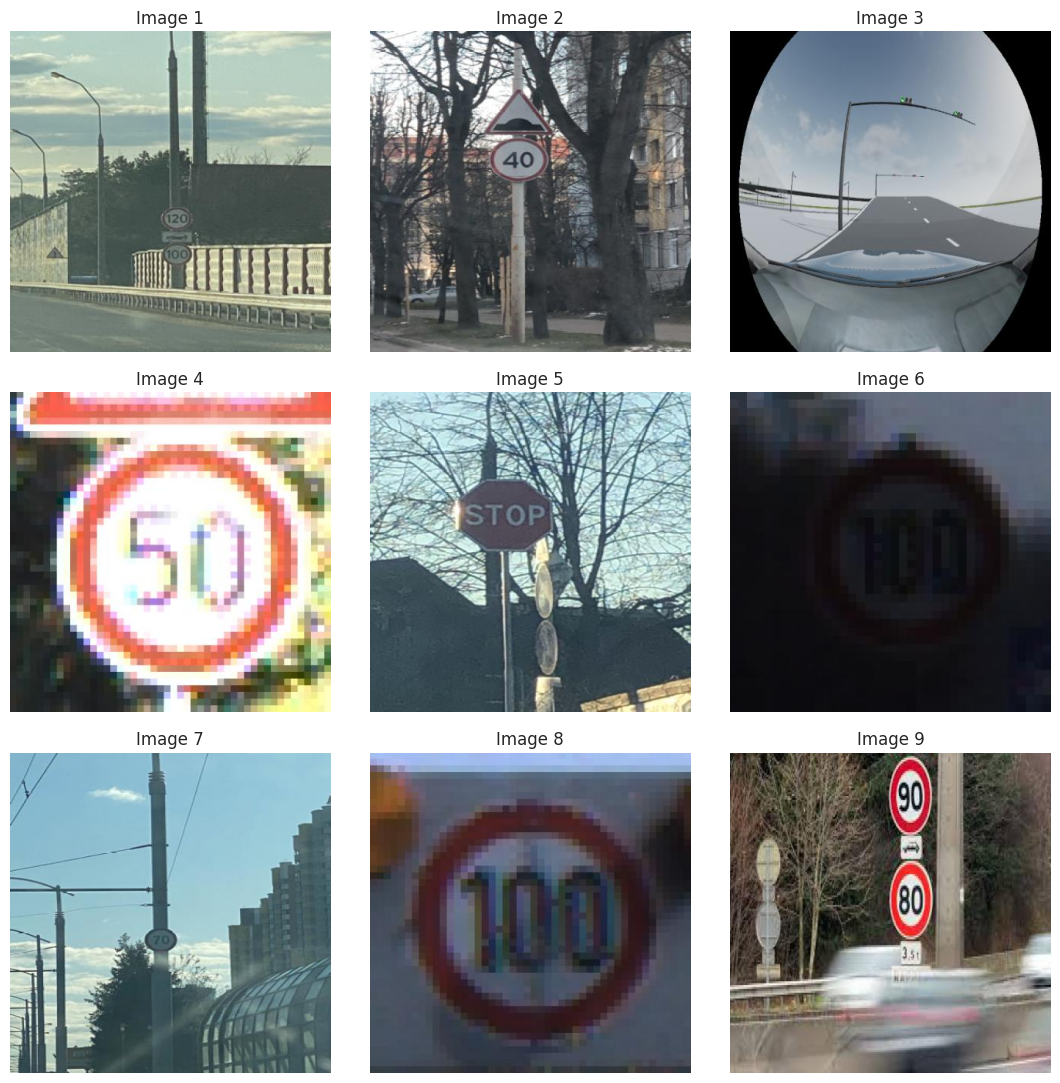

In [30]:
Image_dir = "/content/Traffic/car/train/images"

num_samples = 9
image_files = os.listdir(Image_dir)

# Randomly select num_samples images
rand_images = random.sample(image_files, num_samples)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))

for i in range(num_samples):
    image = rand_images[i]
    ax = axes[i // 3, i % 3]
    ax.imshow(plt.imread(os.path.join(Image_dir, image)))
    ax.set_title(f'Image {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [31]:
import os
img_path = "/content/Traffic/car/train/images/00000_00000_00012_png.rf.23f94508dba03ef2f8bd187da2ec9c26.jpg"
print(os.path.exists(img_path))

True


In [32]:
Image_dir = "/content/Traffic/car/train/images"

image = cv2.imread(os.path.join(Image_dir, "00000_00000_00012_png.rf.23f94508dba03ef2f8bd187da2ec9c26.jpg"))
h, w, c = image.shape
print(f"The image has dimensions {w}x{h} and {c} channels.")

The image has dimensions 416x416 and 3 channels.



image 1/1 /content/Traffic/car/train/images/FisheyeCamera_1_00228_png.rf.e7c43ee9b922f7b2327b8a00ccf46a4c.jpg: 640x640 (no detections), 9.6ms
Speed: 12.4ms preprocess, 9.6ms inference, 6.3ms postprocess per image at shape (1, 3, 640, 640)


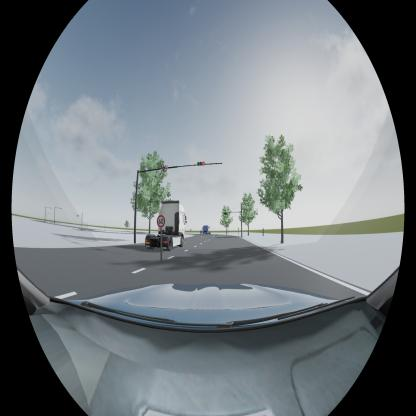

In [33]:
# Use a pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Use the model to detect object
image = "/content/Traffic/car/train/images/FisheyeCamera_1_00228_png.rf.e7c43ee9b922f7b2327b8a00ccf46a4c.jpg"
result_predict = model.predict(source=image, imgsz=(640))

# show results
plot = result_predict[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

In [34]:
!pip install --upgrade ultralytics ray


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 10.9 MB/s eta 0:00:00


In [35]:
with open("/content/Traffic/car/data.yaml", "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 15
names: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']

roboflow:
  workspace: selfdriving-car-qtywx
  project: self-driving-cars-lfjou
  version: 6
  license: CC BY 4.0
  url: https://universe.roboflow.com/selfdriving-car-qtywx/self-driving-cars-lfjou/dataset/6


In [36]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [37]:
# Build from YAML and transfer weights
Final_model = YOLO('yolov8n.pt')

# Training The Final Model
Result_Final_model = Final_model.train(
    data="/content/Traffic/car/data.yaml",
    epochs=30,
    batch=-1,
    optimizer='auto'
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Traffic/car/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False

In [38]:
import os

for root, dirs, files in os.walk('/content/runs'):
    print(root, files[:5])

/content/runs []
/content/runs/detect []
/content/runs/detect/train ['args.yaml', 'train_batch0.jpg', 'confusion_matrix_normalized.png', 'val_batch1_labels.jpg', 'val_batch0_labels.jpg']
/content/runs/detect/train/weights ['best.pt', 'last.pt']


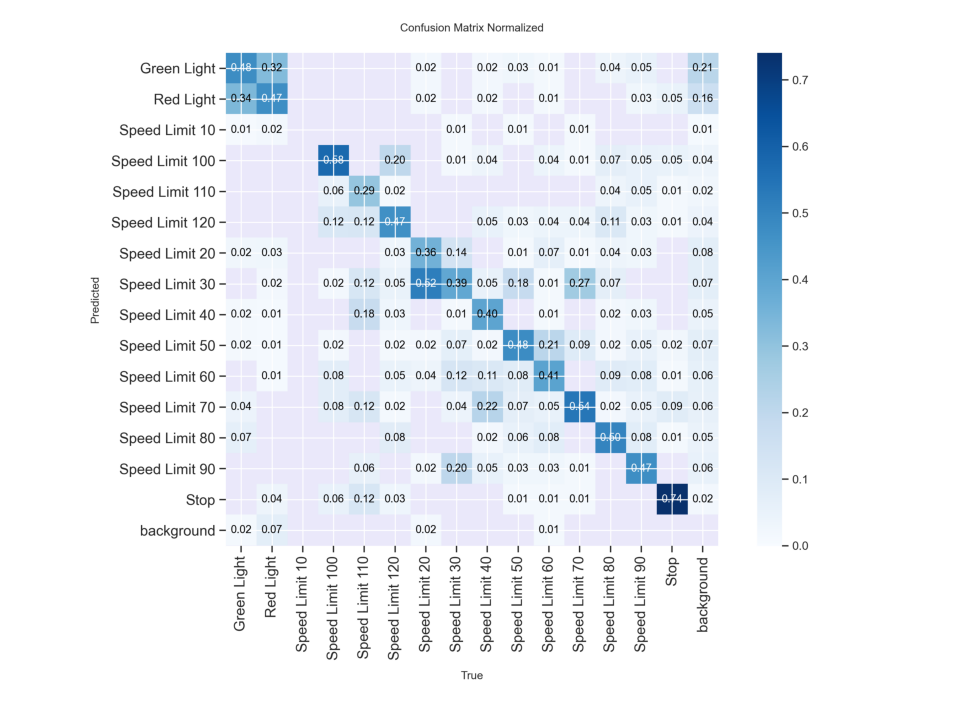

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [39]:
import os
import cv2
import matplotlib.pyplot as plt

def display_images(post_training_files_path, image_files):

    for image_file in image_files:
        image_path = os.path.join(post_training_files_path, image_file)
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 10), dpi=120)
        plt.imshow(img)
        plt.axis('off')
        plt.show()

# List of image files to display
image_files = [
    'confusion_matrix_normalized.png',
    'F1_curve.png',
    'P_curve.png',
    'R_curve.png',
    'PR_curve.png',
    'results.png'
]

# Path to the directory containing the images
post_training_files_path = '/content/runs/detect/train'

# Display the images
display_images(post_training_files_path, image_files)

In [ ]:
import os

print(os.path.exists('/content/runs/detect/train'))
if os.path.exists('/content/runs/detect/train'):
    print(os.listdir('/content/runs/detect/train'))

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

post_training_files_path = '/content/runs/detect/train'

image_files = [f for f in os.listdir(post_training_files_path) if f.endswith('.png')]

for image_file in image_files:
    image_path = os.path.join(post_training_files_path, image_file)
    img = cv2.imread(image_path)

    if img is None:
        print(f" {image_file}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10), dpi=120)
    plt.imshow(img)
    plt.title(image_file)
    plt.axis('off')
    plt.show()

In [ ]:
Result_Final_model = pd.read_csv('/content/runs/detect/train/results.csv')
Result_Final_model.tail(10)

In [ ]:
# Read the results.csv file as a pandas dataframe
Result_Final_model.columns = Result_Final_model.columns.str.strip()

# Create subplots
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))

# Plot the columns using seaborn
sns.lineplot(x='epoch', y='train/box_loss', data=Result_Final_model, ax=axs[0,0])
sns.lineplot(x='epoch', y='train/cls_loss', data=Result_Final_model, ax=axs[0,1])
sns.lineplot(x='epoch', y='train/dfl_loss', data=Result_Final_model, ax=axs[1,0])
sns.lineplot(x='epoch', y='metrics/precision(B)', data=Result_Final_model, ax=axs[1,1])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=Result_Final_model, ax=axs[2,0])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=Result_Final_model, ax=axs[2,1])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=Result_Final_model, ax=axs[3,0])
sns.lineplot(x='epoch', y='val/box_loss', data=Result_Final_model, ax=axs[3,1])
sns.lineplot(x='epoch', y='val/cls_loss', data=Result_Final_model, ax=axs[4,0])
sns.lineplot(x='epoch', y='val/dfl_loss', data=Result_Final_model, ax=axs[4,1])

# Set titles and axis labels for each subplot
axs[0,0].set(title='Train Box Loss')
axs[0,1].set(title='Train Class Loss')
axs[1,0].set(title='Train DFL Loss')
axs[1,1].set(title='Metrics Precision (B)')
axs[2,0].set(title='Metrics Recall (B)')
axs[2,1].set(title='Metrics mAP50 (B)')
axs[3,0].set(title='Metrics mAP50-95 (B)')
axs[3,1].set(title='Validation Box Loss')
axs[4,0].set(title='Validation Class Loss')
axs[4,1].set(title='Validation DFL Loss')


plt.suptitle('Training Metrics and Loss', fontsize=24)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# Loading the best performing model
Valid_model = YOLO('/content/runs/detect/train/weights/best.pt')

# Evaluating the model on the validset
metrics = Valid_model.val(split='val')

# final results
print("precision(B): ", metrics.results_dict["metrics/precision(B)"])
print("metrics/recall(B): ", metrics.results_dict["metrics/recall(B)"])
print("metrics/mAP50(B): ", metrics.results_dict["metrics/mAP50(B)"])
print("metrics/mAP50-95(B): ", metrics.results_dict["metrics/mAP50-95(B)"])

In [ ]:
# Normalization function
def normalize_image(image):
    return image / 255.0

# Image resizing function
def resize_image(image, size=(640, 640)):
    return cv2.resize(image, size)

# Path to validation images
dataset_path = '/content/Traffic/car'  # Place your dataset path here
valid_images_path = os.path.join(dataset_path, 'test', 'images')

# List of all jpg images in the directory
image_files = [file for file in os.listdir(valid_images_path) if file.endswith('.jpg')]

# Check if there are images in the directory
if len(image_files) > 0:
    # Select 9 images at equal intervals
    num_images = len(image_files)
    step_size = max(1, num_images // 9)  # Ensure the interval is at least 1
    selected_images = [image_files[i] for i in range(0, num_images, step_size)]

    # Prepare subplots
    fig, axes = plt.subplots(3, 3, figsize=(20, 21))
    fig.suptitle('Validation Set Inferences', fontsize=24)

    for i, ax in enumerate(axes.flatten()):
        if i < len(selected_images):
            image_path = os.path.join(valid_images_path, selected_images[i])

            # Load image
            image = cv2.imread(image_path)

            # Check if the image is loaded correctly
            if image is not None:
                # Resize image
                resized_image = resize_image(image, size=(640, 640))
                # Normalize image
                normalized_image = normalize_image(resized_image)

                # Convert the normalized image to uint8 data type
                normalized_image_uint8 = (normalized_image * 255).astype(np.uint8)

                # Predict with the model
                results = Valid_model.predict(source=normalized_image_uint8, imgsz=640, conf=0.5)

                # Plot image with labels
                annotated_image = results[0].plot(line_width=1)
                annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
                ax.imshow(annotated_image_rgb)
            else:
                print(f"Failed to load image {image_path}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Convert mp4
!ffmpeg -y -loglevel panic -i /content/video.mp4 output.mp4

# Display the video
Video("output.mp4", width=960)

In [ ]:
import os
print(os.path.exists('output.mp4'))
print(os.path.getsize('output.mp4') / (1024*1024), "MB")

In [ ]:
!ffmpeg -y -i /content/video.mp4 -vcodec libx264 -pix_fmt yuv420p -r 30 output_fixed.mp4

In [ ]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open('output_fixed.mp4', 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=960 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
Valid_model.export(format='onnx')


In [ ]:
pip install ultralytics opencv-python

In [ ]:
from ultralytics import YOLO
import cv2

# Load a pretrained model (n/s/m/l/x = size tradeoff, n is fastest)
model = YOLO("yolov8n.pt")  # downloads automatically first run

# Open your source video
cap = cv2.VideoCapture("input.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("output_fixed.mp4", fourcc, fps, (w, h))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO inference on the frame
    results = model(frame, verbose=False)

    # Draw boxes/labels on the frame
    annotated_frame = results[0].plot()

    out.write(annotated_frame)

cap.release()
out.release()
print("Done — saved to output_fixed.mp4")

In [ ]:
import os
print("Current directory:", os.getcwd())
print("Files here:", os.listdir())

In [ ]:
import os
print(os.listdir())

In [40]:
!pip install ultralytics -q

In [41]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.predict(
    source="Traffic/video.mp4",
    save=True,
    project="runs",
    name="detect",
    conf=0.4


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/508) /content/Traffic/video.mp4: 640x640 1 stop sign, 18.1ms
video 1/1 (frame 2/508) /content/Traffic/video.mp4: 640x640 1 stop sign, 22.9ms
video 1/1 (frame 3/508) /content/Traffic/video.mp4: 640x640 1 stop sign, 25.4ms
video 1/1 (frame 4/508) /content/Traffic/video.mp4: 640x640 (no detections), 43.4ms
video 1/1 (frame 5/508) /content/Traffic/video.mp4: 640x640 (no detections), 30.2ms
video 1/1 (frame 6/508) /content/Traffic/video.mp4

In [45]:
import os

for root, dirs, files in os.walk("runs"):
    for f in files:
        print(os.path.join(root, f))

runs/detect/runs/detect/video.avi
runs/detect/train/args.yaml
runs/detect/train/train_batch0.jpg
runs/detect/train/confusion_matrix_normalized.png
runs/detect/train/val_batch1_labels.jpg
runs/detect/train/val_batch0_labels.jpg
runs/detect/train/val_batch0_pred.jpg
runs/detect/train/val_batch2_pred.jpg
runs/detect/train/results.png
runs/detect/train/BoxR_curve.png
runs/detect/train/train_batch2542.jpg
runs/detect/train/labels.jpg
runs/detect/train/confusion_matrix.png
runs/detect/train/train_batch1.jpg
runs/detect/train/val_batch2_labels.jpg
runs/detect/train/results.csv
runs/detect/train/BoxF1_curve.png
runs/detect/train/BoxPR_curve.png
runs/detect/train/val_batch1_pred.jpg
runs/detect/train/train_batch2540.jpg
runs/detect/train/train_batch2541.jpg
runs/detect/train/train_batch2.jpg
runs/detect/train/BoxP_curve.png
runs/detect/train/weights/best.pt
runs/detect/train/weights/last.pt


In [46]:
import os

output_dir = "runs/detect/runs/detect"
output_file = [f for f in os.listdir(output_dir) if f.endswith((".avi", ".mp4"))][0]
print(" :", output_file)

!ffmpeg -y -i "{output_dir}/{output_file}" -vcodec libx264 -crf 23 output_fixed.mp4

الملف الناتج: video.avi
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbi

In [47]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open('output_fixed.mp4', 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=960 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")